In [33]:
!pip install kaggle wandb onnx -Uq
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [34]:
! mkdir ~/.kaggle
!cp /content/drive/MyDrive/assignment4/kaggle.json ~/.kaggle/kaggle.json
! chmod 600 ~/.kaggle/kaggle.json

mkdir: cannot create directory ‘/root/.kaggle’: File exists


In [35]:
! kaggle competitions download challenges-in-representation-learning-facial-expression-recognition-challenge
! unzip -o challenges-in-representation-learning-facial-expression-recognition-challenge

challenges-in-representation-learning-facial-expression-recognition-challenge.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  challenges-in-representation-learning-facial-expression-recognition-challenge.zip
  inflating: example_submission.csv  
  inflating: fer2013.tar.gz          
  inflating: icml_face_data.csv      
  inflating: test.csv                
  inflating: train.csv               


In [36]:
import torch  # Main PyTorch Library
from torch import nn  # Used for creating the layers and loss function
from torch.optim import AdamW  # AdamW Optimizer (decoupled weight decay)
import torchvision.transforms as transforms  # Transforms to preprocess the images
from torch.utils.data import Dataset, DataLoader  # Dataset class and DataLoader
from sklearn.preprocessing import LabelEncoder  # Encode classes from strings to numbers
import matplotlib.pyplot as plt  # Visualizing images and plotting progress
from PIL import Image  # Read the images
import pandas as pd  # Read/create dataframes (csv)
import numpy as np  # Preprocessing and numerical operations
import os  # Read paths from the directory

device = "cuda" if torch.cuda.is_available() else "cpu"  # use GPU if available
print("Device available: ", device)

Device available:  cuda


In [37]:
import wandb

wandb.login()

PROJECT = "fer2013-facial-expression"

CONFIG = {
    "architecture": "ResNet18",
    "epochs": 40,
    "batch_size": 64,
    "lr": 1e-3,
    "weight_decay": 5e-4,
    "dropout": 0.3,
    "num_classes": 7,
    "img_size": 48,
    "val_split": 0.1,
    "seed": 42,
    "grad_clip": 1.0,
    "label_smoothing": 0.1,
    "lr_step_size": 10,
    "lr_gamma": 0.7,
}

torch.manual_seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])

Shape: (28709, 2)
emotion
Angry       3995
Disgust      436
Fear        4097
Happy       7215
Sad         4830
Surprise    3171
Neutral     4965
Name: count, dtype: int64


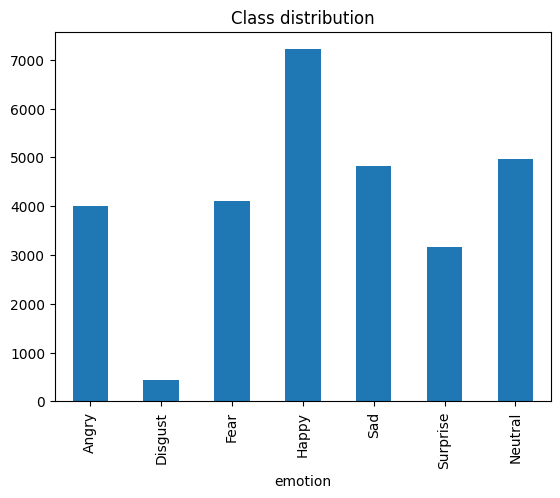

,emotion,pixels
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...
1,0,151 150 147 155 148 133 111 140 170 174 182 15...
2,2,231 212 156 164 174 138 161 173 182 200 106 38...
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...


In [38]:
df = pd.read_csv("train.csv")
print("Shape:", df.shape)

EMOTIONS = {0: "Angry", 1: "Disgust", 2: "Fear", 3: "Happy", 4: "Sad", 5: "Surprise", 6: "Neutral"}

counts = df["emotion"].value_counts().sort_index()
print(counts.rename(index=EMOTIONS))
counts.rename(index=EMOTIONS).plot(kind="bar", title="Class distribution"); plt.show()
df.head()

In [39]:

from sklearn.model_selection import train_test_split

le = LabelEncoder()
df["label"] = le.fit_transform(df["emotion"])

train_df, val_df = train_test_split(
    df, test_size=CONFIG["val_split"], random_state=CONFIG["seed"],
    stratify=df["label"],
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
print(f"Train: {len(train_df)} | Val: {len(val_df)}")

Train: 25838 | Val: 2871


In [40]:
class FERDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.pixels = dataframe["pixels"].values
        self.labels = dataframe["label"].values if "label" in dataframe.columns else None
        self.transform = transform

    def __len__(self):
        return len(self.pixels)

    def __getitem__(self, idx):
        pix = np.array(self.pixels[idx].split(), dtype=np.uint8).reshape(48, 48)
        img = Image.fromarray(pix)            # 8-bit grayscale
        if self.transform:
            img = self.transform(img)
        if self.labels is not None:
            return img, int(self.labels[idx])
        return img

In [41]:
train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomAffine(0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.2),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])
eval_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

train_ds = FERDataset(train_df, transform=train_tf)
val_ds   = FERDataset(val_df,   transform=eval_tf)

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"],
                          shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"],
                          shuffle=False, num_workers=2, pin_memory=True)

print("Train batches:", len(train_loader), "| Val batches:", len(val_loader))

Train batches: 404 | Val batches: 45


In [42]:
class ResidualBlock(nn.Module):

    def __init__(self, in_c, out_c, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_c, out_c, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_c)
        self.conv2 = nn.Conv2d(out_c, out_c, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_c)
        self.relu  = nn.ReLU(inplace=True)


        self.shortcut = nn.Sequential()
        if stride != 1 or in_c != out_c:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_c, out_c, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_c),
            )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x)
        return self.relu(out)


class ResNet(nn.Module):

    def __init__(self, num_classes=7, dropout=0.3):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
        )
        self.layer1 = self._make_layer(64,  64,  blocks=2, stride=1)
        self.layer2 = self._make_layer(64,  128, blocks=2, stride=2)
        self.layer3 = self._make_layer(128, 256, blocks=2, stride=2)
        self.layer4 = self._make_layer(256, 512, blocks=2, stride=2)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes),
        )

    def _make_layer(self, in_c, out_c, blocks, stride):
        layers = [ResidualBlock(in_c, out_c, stride)]
        for _ in range(blocks - 1):
            layers.append(ResidualBlock(out_c, out_c, 1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x); x = self.layer2(x); x = self.layer3(x); x = self.layer4(x)
        x = self.pool(x)
        return self.classifier(x)

In [43]:
def train_one_epoch(model, loader, criterion, optimizer, grad_clip=None):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
        correct += (logits.argmax(1) == yb).sum().item()
        total += xb.size(0)
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = criterion(logits, yb)
        running_loss += loss.item() * xb.size(0)
        correct += (logits.argmax(1) == yb).sum().item()
        total += xb.size(0)
    return running_loss / total, correct / total

In [44]:
run = wandb.init(
    project=PROJECT,
    name=CONFIG["architecture"],
    config=CONFIG,
    reinit=True,
)
from sklearn.utils.class_weight import compute_class_weight
w = compute_class_weight("balanced", classes=np.unique(train_df["label"]), y=train_df["label"])
class_weights = torch.tensor(w, dtype=torch.float).to(device)

model = ResNet(num_classes=CONFIG["num_classes"], dropout=CONFIG["dropout"]).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights,
                                label_smoothing=CONFIG["label_smoothing"])
optimizer = AdamW(model.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer, step_size=CONFIG["lr_step_size"], gamma=CONFIG["lr_gamma"])

wandb.watch(model, criterion, log="all", log_freq=100)

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0

for epoch in range(CONFIG["epochs"]):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer,
                                      grad_clip=CONFIG["grad_clip"])
    val_loss, val_acc = evaluate(model, val_loader, criterion)
    scheduler.step()                              # stepwise decay, once per epoch

    history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
    history["val_loss"].append(val_loss);  history["val_acc"].append(val_acc)

    wandb.log({
        "epoch": epoch,
        "train_loss": tr_loss, "train_acc": tr_acc,
        "val_loss": val_loss,  "val_acc": val_acc,
        "lr": optimizer.param_groups[0]["lr"],
    })
    print(f"Epoch {epoch+1:02d}/{CONFIG['epochs']} "
          f"train_loss {tr_loss:.4f} acc {tr_acc:.4f} "
          f"val_loss {val_loss:.4f} acc {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pt")

wandb.summary["best_val_acc"] = best_val_acc
print("Best val accuracy:", best_val_acc)

Epoch 01/40 train_loss 2.1990 acc 0.0857 val_loss 2.1778 acc 0.2055
Epoch 02/40 train_loss 2.1453 acc 0.0527 val_loss 2.1158 acc 0.0237
Epoch 03/40 train_loss 2.0996 acc 0.0790 val_loss 2.0484 acc 0.0982
Epoch 04/40 train_loss 1.9729 acc 0.2415 val_loss 1.8970 acc 0.3995
Epoch 05/40 train_loss 1.8949 acc 0.3256 val_loss 1.9810 acc 0.3560
Epoch 06/40 train_loss 1.8579 acc 0.3583 val_loss 1.8097 acc 0.3393
Epoch 07/40 train_loss 1.8210 acc 0.3965 val_loss 1.7687 acc 0.4340
Epoch 08/40 train_loss 1.7916 acc 0.4238 val_loss 1.7192 acc 0.4626
Epoch 09/40 train_loss 1.7590 acc 0.4475 val_loss 1.7197 acc 0.4591
Epoch 10/40 train_loss 1.7368 acc 0.4603 val_loss 1.6770 acc 0.5165
Epoch 11/40 train_loss 1.6877 acc 0.4856 val_loss 1.6501 acc 0.5082
Epoch 12/40 train_loss 1.6755 acc 0.5033 val_loss 1.6542 acc 0.5545
Epoch 13/40 train_loss 1.6516 acc 0.5190 val_loss 1.6215 acc 0.5416
Epoch 14/40 train_loss 1.6366 acc 0.5276 val_loss 1.6008 acc 0.5563
Epoch 15/40 train_loss 1.6169 acc 0.5387 val_los

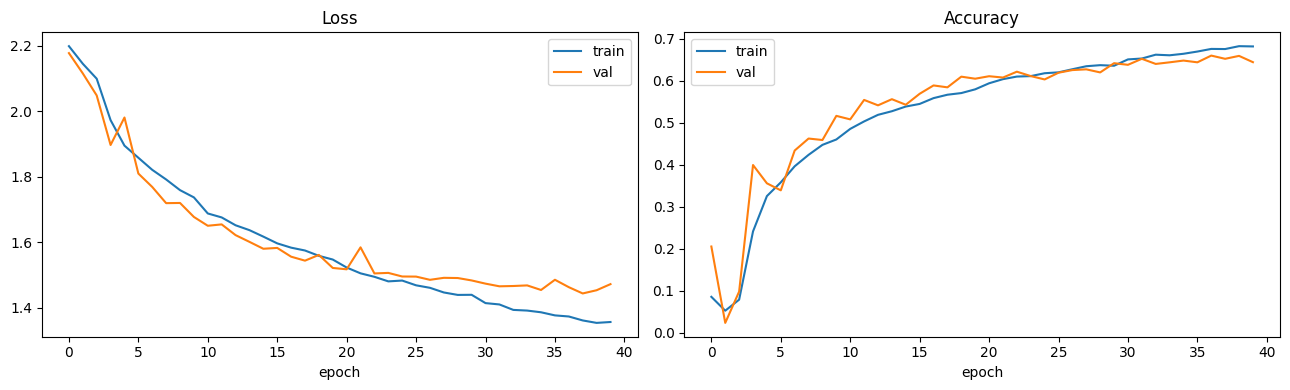

Best val: 0.6600
Final train-val accuracy gap: 0.0375


In [45]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(history["train_loss"], label="train")
ax1.plot(history["val_loss"], label="val")
ax1.set_title("Loss"); ax1.set_xlabel("epoch"); ax1.legend()

ax2.plot(history["train_acc"], label="train")
ax2.plot(history["val_acc"], label="val")
ax2.set_title("Accuracy"); ax2.set_xlabel("epoch"); ax2.legend()
plt.tight_layout(); plt.show()

print(f"Best val: {best_val_acc:.4f}")
print(f"Final train-val accuracy gap: {history['train_acc'][-1] - history['val_acc'][-1]:.4f}")

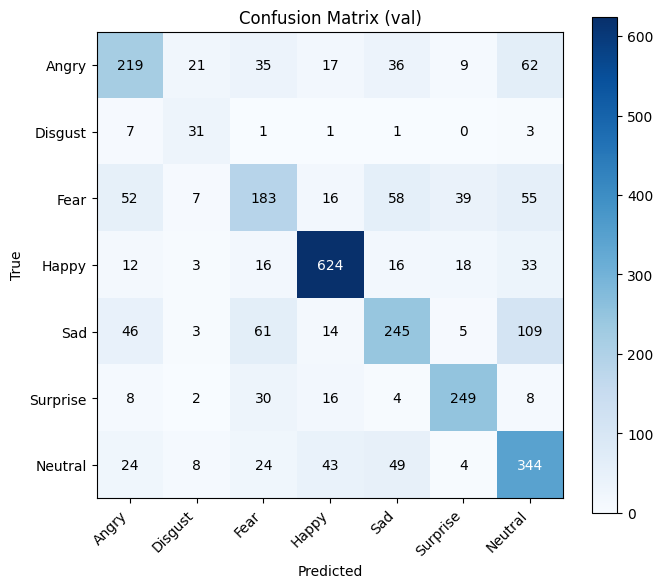

              precision    recall  f1-score   support

       Angry       0.60      0.55      0.57       399
     Disgust       0.41      0.70      0.52        44
        Fear       0.52      0.45      0.48       410
       Happy       0.85      0.86      0.86       722
         Sad       0.60      0.51      0.55       483
    Surprise       0.77      0.79      0.78       317
     Neutral       0.56      0.69      0.62       496

    accuracy                           0.66      2871
   macro avg       0.62      0.65      0.63      2871
weighted avg       0.66      0.66      0.66      2871



In [46]:
from sklearn.metrics import confusion_matrix, classification_report

model.load_state_dict(torch.load("best_model.pt", map_location=device))
model.eval()

all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in val_loader:
        logits = model(xb.to(device))
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_true.extend(yb.numpy())

cm = confusion_matrix(all_true, all_preds)
class_names = [EMOTIONS[c] for c in le.classes_]

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(class_names))); ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticks(range(len(class_names))); ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title("Confusion Matrix (val)")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
fig.colorbar(im); plt.tight_layout(); plt.show()

print(classification_report(all_true, all_preds, target_names=class_names))

wandb.log({"val_confusion_matrix": wandb.plot.confusion_matrix(
    y_true=all_true, preds=all_preds, class_names=class_names)})

In [47]:
test_df = pd.read_csv("test.csv")
print("Test samples:", len(test_df))

test_ds = FERDataset(test_df, transform=eval_tf)
test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False)

model.load_state_dict(torch.load("best_model.pt", map_location=device))
model.eval()

preds = []
with torch.no_grad():
    for xb in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        preds.extend(logits.argmax(1).cpu().numpy().tolist())

emotion_preds = le.inverse_transform(np.array(preds))
submission = pd.DataFrame({"emotion": emotion_preds})
submission.index.name = "id"
submission.to_csv("submission.csv")
print("Wrote submission.csv")
submission.head()

Test samples: 7178
Wrote submission.csv


,emotion
id,
0,0
1,1
2,0
3,6
4,3


In [48]:
wandb.finish()

epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
lr,█████████▅▅▅▅▅▅▅▅▅▅▃▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁
train_acc,▁▁▁▃▄▄▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇██████████
train_loss,██▇▆▅▅▅▅▄▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
val_acc,▃▁▂▅▅▄▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇█▇▇███████████████
val_loss,█▇▇▅▆▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_val_acc,0.66005
epoch,39
lr,0.00024
train_acc,0.68186
train_loss,1.35583
